Coefficient (theta1) : 1.738487910495198
Biais (theta0)      : 1.0812547549176308
Précision : 40.0 %
Résultat : ADMIS


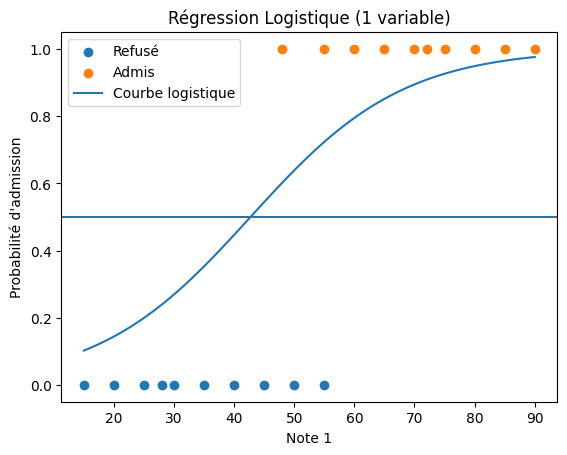

In [6]:
# Importer les bibliothèques nécessaires
import numpy as np  # Pour manipuler les tableaux (matrices)
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression  # Modèle de régression logistique
from sklearn.preprocessing import StandardScaler  # Pour normaliser les données
from sklearn.model_selection import train_test_split  # Pour séparer train/test
from sklearn.metrics import accuracy_score  # Pour calculer la précision

# ==========================================================
# 1. DONNÉES
# ==========================================================

# X contient les notes des étudiants (Note1, Note2)
X = np.array([
    [45, 50], [50, 55], [55, 60], [60, 65], [65, 70],
    [30, 35], [35, 40], [40, 45], [25, 30], [28, 32],
    [70, 75], [75, 80], [80, 85], [85, 90], [90, 95],
    [20, 25], [15, 20], [55, 45], [48, 62], [72, 58]
])

# y contient les résultats (1 = Admis, 0 = Refusé)
y = np.array([
    0, 0, 1, 1, 1,
    0, 0, 0, 0, 0,
    1, 1, 1, 1, 1,
    0, 0, 0, 1, 1
])

# ==========================================================
# 2. SÉPARATION TRAIN / TEST
# ==========================================================

# On divise les données :
# 75% pour entraîner le modèle
# 25% pour tester le modèle
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ==========================================================
# 3. NORMALISATION
# ==========================================================

# Création du normaliseur
scaler = StandardScaler()

# Calcul de la moyenne + écart-type sur le train et transformation
X_train_scaled = scaler.fit_transform(X_train)

# Transformation du test avec les mêmes valeurs (IMPORTANT)
X_test_scaled = scaler.transform(X_test)

# ==========================================================
# 4. MODÈLE SIMPLE (1 seule variable)
# ==========================================================

# On prend uniquement la première colonne (Note1)
X_train_simple = X_train_scaled[:, 0].reshape(-1, 1)
X_test_simple = X_test_scaled[:, 0].reshape(-1, 1)

# Création du modèle
model = LogisticRegression()

# Entraînement du modèle avec les données d'entraînement
model.fit(X_train_simple, y_train)

# ==========================================================
# 5. RÉSULTATS
# ==========================================================

# Afficher le coefficient (importance de Note1)
print("Coefficient (theta1) :", model.coef_[0][0])

# Afficher le biais
print("Biais (theta0)      :", model.intercept_[0])

# Faire des prédictions sur le test
y_pred = model.predict(X_test_simple)

# Calculer la précision (accuracy)
accuracy = accuracy_score(y_test, y_pred)
print("Précision :", accuracy * 100, "%")

# ==========================================================
# 6. TEST SUR UN NOUVEL ÉTUDIANT
# ==========================================================

# Nouvel étudiant avec Note1 = 70
# (on met 2 valeurs pour respecter la structure des données)
nouvel_etudiant = np.array([[70, 0]])

# Normaliser avec le même scaler
nouvel_etudiant_scaled = scaler.transform(nouvel_etudiant)

# Prédire (on utilise seulement Note1)
prediction = model.predict(nouvel_etudiant_scaled[:, 0].reshape(-1, 1))

# Afficher le résultat
if prediction[0] == 1:
    print("Résultat : ADMIS")
else:
    print("Résultat : REFUSÉ")


# ==========================================================
# 7. GRAPHIQUE (VISUALISATION)
# ==========================================================

# On récupère seulement Note1
X_plot = X[:, 0]
y_plot = y

# Créer des points pour tracer la courbe
x_vals = np.linspace(min(X_plot), max(X_plot), 100).reshape(-1, 1)

# Normaliser ces valeurs
x_vals_scaled = scaler.transform(np.c_[x_vals, np.zeros_like(x_vals)])

# Calcul des probabilités
y_probs = model.predict_proba(x_vals_scaled[:, 0].reshape(-1, 1))[:, 1]

# Tracer les points
plt.scatter(X_plot[y_plot == 0], y_plot[y_plot == 0], label="Refusé")
plt.scatter(X_plot[y_plot == 1], y_plot[y_plot == 1], label="Admis")

# Tracer la courbe logistique
plt.plot(x_vals, y_probs, label="Courbe logistique")

# Ligne seuil (0.5)
plt.axhline(0.5)

plt.xlabel("Note 1")
plt.ylabel("Probabilité d'admission")
plt.title("Régression Logistique (1 variable)")
plt.legend()

plt.show()


theta0 : 0.0004525499368873621
theta1 : 5.161742439798339
Étudiant Note1 = 70 → ADMIS


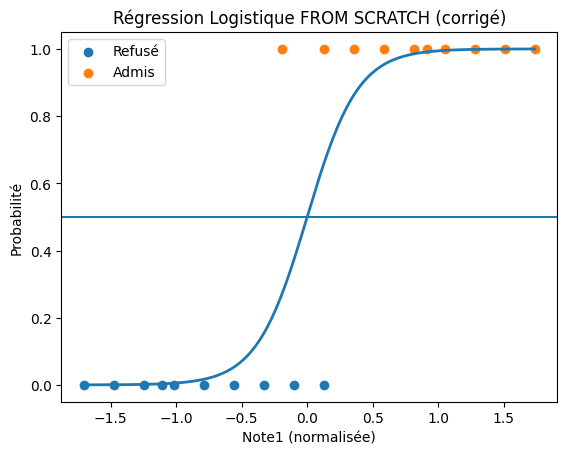

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. DONNÉES
# ==========================================================
X = np.array([
    [45, 50], [50, 55], [55, 60], [60, 65], [65, 70],
    [30, 35], [35, 40], [40, 45], [25, 30], [28, 32],
    [70, 75], [75, 80], [80, 85], [85, 90], [90, 95],
    [20, 25], [15, 20], [55, 45], [48, 62], [72, 58]
])

y = np.array([
    0, 0, 1, 1, 1,
    0, 0, 0, 0, 0,
    1, 1, 1, 1, 1,
    0, 0, 0, 1, 1
])

# ==========================================================
# 2. PRENDRE UNE SEULE VARIABLE (Note1)
# ==========================================================
X = X[:, 0]

# ==========================================================
# 3. NORMALISATION
# ==========================================================
mean = np.mean(X)
std = np.std(X)
X = (X - mean) / std

# ==========================================================
# 4. SIGMOÏDE
# ==========================================================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ==========================================================
# 5. INITIALISATION (IMPORTANT)
# ==========================================================
theta0 = np.random.randn()
theta1 = np.random.randn()

learning_rate = 0.05
epochs = 5000

# ==========================================================
# 6. DESCENTE DE GRADIENT
# ==========================================================
for i in range(epochs):
    z = theta0 + theta1 * X
    y_pred = sigmoid(z)

    # gradients
    d_theta0 = np.mean(y_pred - y)
    d_theta1 = np.mean((y_pred - y) * X)

    # mise à jour
    theta0 -= learning_rate * d_theta0
    theta1 -= learning_rate * d_theta1

# ==========================================================
# 7. AFFICHAGE PARAMÈTRES
# ==========================================================
print("theta0 :", theta0)
print("theta1 :", theta1)

# ==========================================================
# 8. PRÉDICTION
# ==========================================================
def predict(x):
    x_norm = (x - mean) / std
    prob = sigmoid(theta0 + theta1 * x_norm)
    return 1 if prob >= 0.5 else 0

print("Étudiant Note1 = 70 →", "ADMIS" if predict(70) else "REFUSÉ")

# ==========================================================
# 9. GRAPHIQUE
# ==========================================================
# Courbe
x_vals = np.linspace(min(X), max(X), 200)
y_vals = sigmoid(theta0 + theta1 * x_vals)

# Points
plt.scatter(X[y == 0], y[y == 0], label="Refusé")
plt.scatter(X[y == 1], y[y == 1], label="Admis")

# Courbe sigmoïde
plt.plot(x_vals, y_vals, linewidth=2)

# Ligne seuil
plt.axhline(0.5)

plt.title("Régression Logistique FROM SCRATCH (corrigé)")
plt.xlabel("Note1 (normalisée)")
plt.ylabel("Probabilité")

plt.legend()
plt.show()
